# 週次「割安高質」戦略バックテスト（最適化版）

**作成日**: 2026-02-18

**最適化ポイント**:
- データの事前フィルタリング
- ピボットテーブル化で高速アクセス
- ベクトル化処理

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['MS Gothic', 'Yu Gothic', 'Meiryo']
plt.rcParams['axes.unicode_minus'] = False

print("ライブラリインポート完了")

ライブラリインポート完了


## 1. データ読み込み・前処理

In [ ]:
PROJECT_ROOT = Path(r'C:\Users\yongr\claude project\workspace')

# 価格データ
print("価格データ読み込み中...")
df_price = pd.read_parquet(PROJECT_ROOT / 'data/curated/jquants/prices/daily_quotes_all.parquet')
df_price['date'] = pd.to_datetime(df_price['date'])

# 期間フィルタ（2017年以降）
df_price = df_price[df_price['date'] >= '2017-01-01'].copy()
print(f"価格データ: {len(df_price):,} 行")

# 財務データ
print("財務データ読み込み中...")
df_fin = pd.read_parquet(PROJECT_ROOT / 'data/curated/jquants/financials/statements_all.parquet')
df_fin['disclosed_date'] = pd.to_datetime(df_fin['disclosed_date'])
df_fin = df_fin[df_fin['disclosed_date'] >= '2017-01-01'].copy()

# 【重要】年次決算のみに限定（年次戦略と同じロジック）
if 'fiscal_quarter' in df_fin.columns:
    before_count = len(df_fin)
    df_fin = df_fin[df_fin['fiscal_quarter'] == 'FY'].copy()
    print(f"年次決算フィルタ: {before_count:,} → {len(df_fin):,} 行（{len(df_fin)/before_count*100:.1f}%）")
else:
    print("警告: fiscal_quarter列が存在しません。全ての決算データを使用します。")

# 必須カラムのみ抽出
df_fin = df_fin[['disclosed_date', 'code', 'equity', 'net_profit', 'bps']].copy()

# ROE計算
df_fin['roe'] = (df_fin['net_profit'] / df_fin['equity']) * 100

# 異常値除外
df_fin = df_fin[
    (df_fin['roe'] > -100) & (df_fin['roe'] < 100) &
    (df_fin['bps'] > 0) & (df_fin['equity'] > 0)
].copy()

print(f"財務データ（年次のみ、異常値除外後）: {len(df_fin):,} 行")
print("前処理完了")

## 2. 価格データのピボット化（高速アクセス用）

In [3]:
print("価格データをピボット化中...")
df_price_pivot = df_price.pivot(index='date', columns='code', values='close')
print(f"ピボットテーブル: {df_price_pivot.shape[0]} 日 × {df_price_pivot.shape[1]} 銘柄")
print("ピボット化完了")

価格データをピボット化中...
ピボットテーブル: 2216 日 × 5226 銘柄
ピボット化完了


## 3. リバランス日生成

In [4]:
# 週の最終営業日
trading_days = pd.Series(df_price_pivot.index).reset_index(drop=True)
trading_days_df = pd.DataFrame({'date': trading_days})
trading_days_df['year'] = trading_days_df['date'].dt.year
trading_days_df['week'] = trading_days_df['date'].dt.isocalendar().week
rebalance_dates = trading_days_df.groupby(['year', 'week'])['date'].max().values
rebalance_dates = pd.Series(rebalance_dates).sort_values().reset_index(drop=True)

print(f"リバランス日数: {len(rebalance_dates)}")
print(f"期間: {rebalance_dates.iloc[0].date()} ~ {rebalance_dates.iloc[-1].date()}")

リバランス日数: 472
期間: 2017-01-06 ~ 2026-02-17


## 4. 財務データの事前処理（各日の最新データを準備）

In [5]:
print("財務データの事前処理中（時間がかかります）...")

# 各リバランス日での利用可能な財務データを事前計算
fin_by_date = {}

for i, rdate in enumerate(rebalance_dates):
    if i % 50 == 0:
        print(f"  進捗: {i}/{len(rebalance_dates)}")
    
    # その日までに開示された財務データ
    available = df_fin[df_fin['disclosed_date'] <= rdate].copy()
    
    # 各銘柄の最新データ
    latest = available.sort_values('disclosed_date').groupby('code').tail(1)
    latest = latest.set_index('code')[['bps', 'roe']]
    
    fin_by_date[rdate] = latest

print("財務データ事前処理完了")

財務データの事前処理中（時間がかかります）...
  進捗: 0/472
  進捗: 50/472
  進捗: 100/472
  進捗: 150/472
  進捗: 200/472
  進捗: 250/472
  進捗: 300/472
  進捗: 350/472
  進捗: 400/472
  進捗: 450/472
財務データ事前処理完了


## 5. 高速スクリーニング関数

In [6]:
def screen_stocks_fast(rebalance_date, prices_pivot, fin_data, n_stocks=20):
    """
    高速版銘柄スクリーニング
    """
    # その日の価格
    if rebalance_date not in prices_pivot.index:
        return pd.DataFrame()
    
    prices = prices_pivot.loc[rebalance_date].dropna()
    
    # 財務データ（事前計算済み）
    if rebalance_date not in fin_data:
        return pd.DataFrame()
    
    fin = fin_data[rebalance_date]
    
    # マージ
    merged = pd.DataFrame({
        'close': prices,
        'bps': fin['bps'],
        'roe': fin['roe']
    }).dropna()
    
    if len(merged) < n_stocks:
        return pd.DataFrame()
    
    # PBR計算
    merged['pbr'] = merged['close'] / merged['bps']
    
    # 異常値除外
    merged = merged[(merged['pbr'] > 0) & (merged['pbr'] < 50)]
    
    if len(merged) < n_stocks:
        return pd.DataFrame()
    
    # 四分位
    pbr_q1 = merged['pbr'].quantile(0.25)
    roe_q3 = merged['roe'].quantile(0.75)
    
    # 割安高質
    candidates = merged[(merged['pbr'] <= pbr_q1) & (merged['roe'] >= roe_q3)]
    
    if len(candidates) < n_stocks:
        candidates = merged.nsmallest(n_stocks, 'pbr')
    
    selected = candidates.nsmallest(n_stocks, 'pbr')
    return selected.reset_index()

# テスト
test_date = rebalance_dates.iloc[10]
test_result = screen_stocks_fast(test_date, df_price_pivot, fin_by_date)
print(f"テスト: {len(test_result)} 銘柄選定")
display(test_result.head())

テスト: 20 銘柄選定


,code,close,bps,roe,pbr
0,39400,81.4,1043.84,10.031024,0.077981
1,23170,105.7,574.67,11.203233,0.183932
2,24710,64.7,344.52,39.193084,0.187798
3,74190,228.7,1066.37,12.123857,0.214466
4,80010,330.4,1512.61,11.440596,0.218430


## 6. バックテストループ（最適化版）

In [ ]:
# パラメータ
INITIAL_CASH = 10_000_000
N_STOCKS = 20
TAX_RATE = 0.20315
UNIT = 100

# 初期化
cash = INITIAL_CASH
portfolio = {}  # {code: {'shares': int, 'buy_price': float}}
annual_realized_pnl = 0
current_year = None
results = []

print("バックテスト開始（最適化版）...")
print(f"初期資本: {INITIAL_CASH:,}円")
print(f"リバランス回数: {len(rebalance_dates)}")
print()

for i, rebalance_date in enumerate(rebalance_dates):
    # 進捗表示（頻度アップ）
    if i % 10 == 0:
        print(f"進捗: {i}/{len(rebalance_dates)} ({i/len(rebalance_dates)*100:.1f}%) - {rebalance_date.date()}")
    
    # 年の切り替わり
    if current_year != rebalance_date.year:
        if current_year is not None and annual_realized_pnl > 0:
            tax = annual_realized_pnl * TAX_RATE
            cash -= tax
        annual_realized_pnl = 0
        current_year = rebalance_date.year
    
    # 既存ポートフォリオ売却
    sell_value = 0
    if rebalance_date in df_price_pivot.index:
        for code, position in portfolio.items():
            if code in df_price_pivot.columns:
                sell_price = df_price_pivot.loc[rebalance_date, code]
                if pd.notna(sell_price):
                    sell_amount = position['shares'] * sell_price
                    sell_value += sell_amount
                    pnl = (sell_price - position['buy_price']) * position['shares']
                    annual_realized_pnl += pnl
    
    cash += sell_value
    portfolio = {}
    
    # 銘柄選定
    selected = screen_stocks_fast(rebalance_date, df_price_pivot, fin_by_date, N_STOCKS)
    
    if len(selected) == 0:
        results.append({
            'date': rebalance_date,
            'cash': cash,
            'n_stocks': 0,
            'invested': 0,
            'annual_pnl': annual_realized_pnl,
            'portfolio': {}
        })
        continue
    
    # 購入
    target_per_stock = cash / len(selected)
    total_invested = 0
    
    for _, row in selected.iterrows():
        code = row['code']
        price = row['close']
        shares = int(target_per_stock / (price * UNIT)) * UNIT
        
        if shares > 0:
            invest_amount = shares * price
            total_invested += invest_amount
            portfolio[code] = {'shares': shares, 'buy_price': price}
    
    cash -= total_invested
    
    results.append({
        'date': rebalance_date,
        'cash': cash,
        'n_stocks': len(portfolio),
        'invested': total_invested,
        'annual_pnl': annual_realized_pnl,
        'portfolio': portfolio.copy()
    })

# 最終税金
if annual_realized_pnl > 0:
    tax = annual_realized_pnl * TAX_RATE
    cash -= tax
    # 税金支払い後の現金を最終行に反映
    results[-1]['cash'] = cash

# 【重要】最終日時点での保有株式を時価評価
final_date = df_price_pivot.index.max()
final_portfolio_value = 0
print(f"\n最終リバランス日: {results[-1]['date'].date()}")
print(f"最終営業日: {final_date.date()}")

if len(portfolio) > 0:
    for code, position in portfolio.items():
        if code in df_price_pivot.columns:
            final_price = df_price_pivot.loc[final_date, code]
            if pd.notna(final_price):
                final_portfolio_value += position['shares'] * final_price
    
    # 最終行の結果を時価評価で更新
    results[-1]['invested'] = final_portfolio_value
    print(f"最終保有株式を時価評価に更新: {final_portfolio_value:,.0f}円")
else:
    print("最終ポートフォリオは空です")

print("\nバックテスト完了")
print(f"最終現金（税引後）: {cash:,.0f}円")
print(f"最終保有銘柄数: {len(portfolio)}")
print(f"最終保有株式時価: {final_portfolio_value:,.0f}円")
print(f"最終総資産（時価評価後）: {(cash + final_portfolio_value):,.0f}円")

## 7. パフォーマンス分析

In [8]:
df_results = pd.DataFrame(results)
df_results['total_value'] = df_results['cash'] + df_results['invested']
df_results['return'] = df_results['total_value'].pct_change()
df_results['cumulative_return'] = (1 + df_results['return']).cumprod() - 1

print("=" * 60)
print("パフォーマンスサマリ")
print("=" * 60)
print(f"期間: {df_results['date'].iloc[0].date()} ~ {df_results['date'].iloc[-1].date()}")
print(f"初期資本: {INITIAL_CASH:,}円")
print(f"最終資産: {df_results['total_value'].iloc[-1]:,.0f}円")
print(f"総リターン: {df_results['cumulative_return'].iloc[-1]*100:.2f}%")
print()

# 年率換算
years = (df_results['date'].iloc[-1] - df_results['date'].iloc[0]).days / 365.25
total_return = df_results['cumulative_return'].iloc[-1]
annual_return = (1 + total_return) ** (1 / years) - 1

print(f"運用期間: {years:.2f}年")
print(f"年率リターン: {annual_return*100:.2f}%")
print(f"年率ボラティリティ: {df_results['return'].std() * np.sqrt(52)*100:.2f}%")

# MDD
df_results['peak'] = df_results['total_value'].cummax()
df_results['drawdown'] = (df_results['total_value'] - df_results['peak']) / df_results['peak']
mdd = df_results['drawdown'].min()
mdd_date = df_results.loc[df_results['drawdown'].idxmin(), 'date']

print(f"最大ドローダウン: {mdd*100:.2f}%（{mdd_date.date()}）")

# Sharpe, Calmar
sharpe = df_results['return'].mean() / df_results['return'].std() * np.sqrt(52)
calmar = annual_return / abs(mdd)

print(f"シャープレシオ: {sharpe:.2f}")
print(f"カルマー比: {calmar:.2f}")
print("=" * 60)

パフォーマンスサマリ
期間: 2017-01-06 ~ 2026-02-17
初期資本: 10,000,000円
最終資産: 1,021,654円
総リターン: -89.78%

運用期間: 9.11年
年率リターン: -22.14%
年率ボラティリティ: 28.13%
最大ドローダウン: -93.37%（2026-02-13）
シャープレシオ: -0.71
カルマー比: -0.24


## 8. ビジュアライゼーション

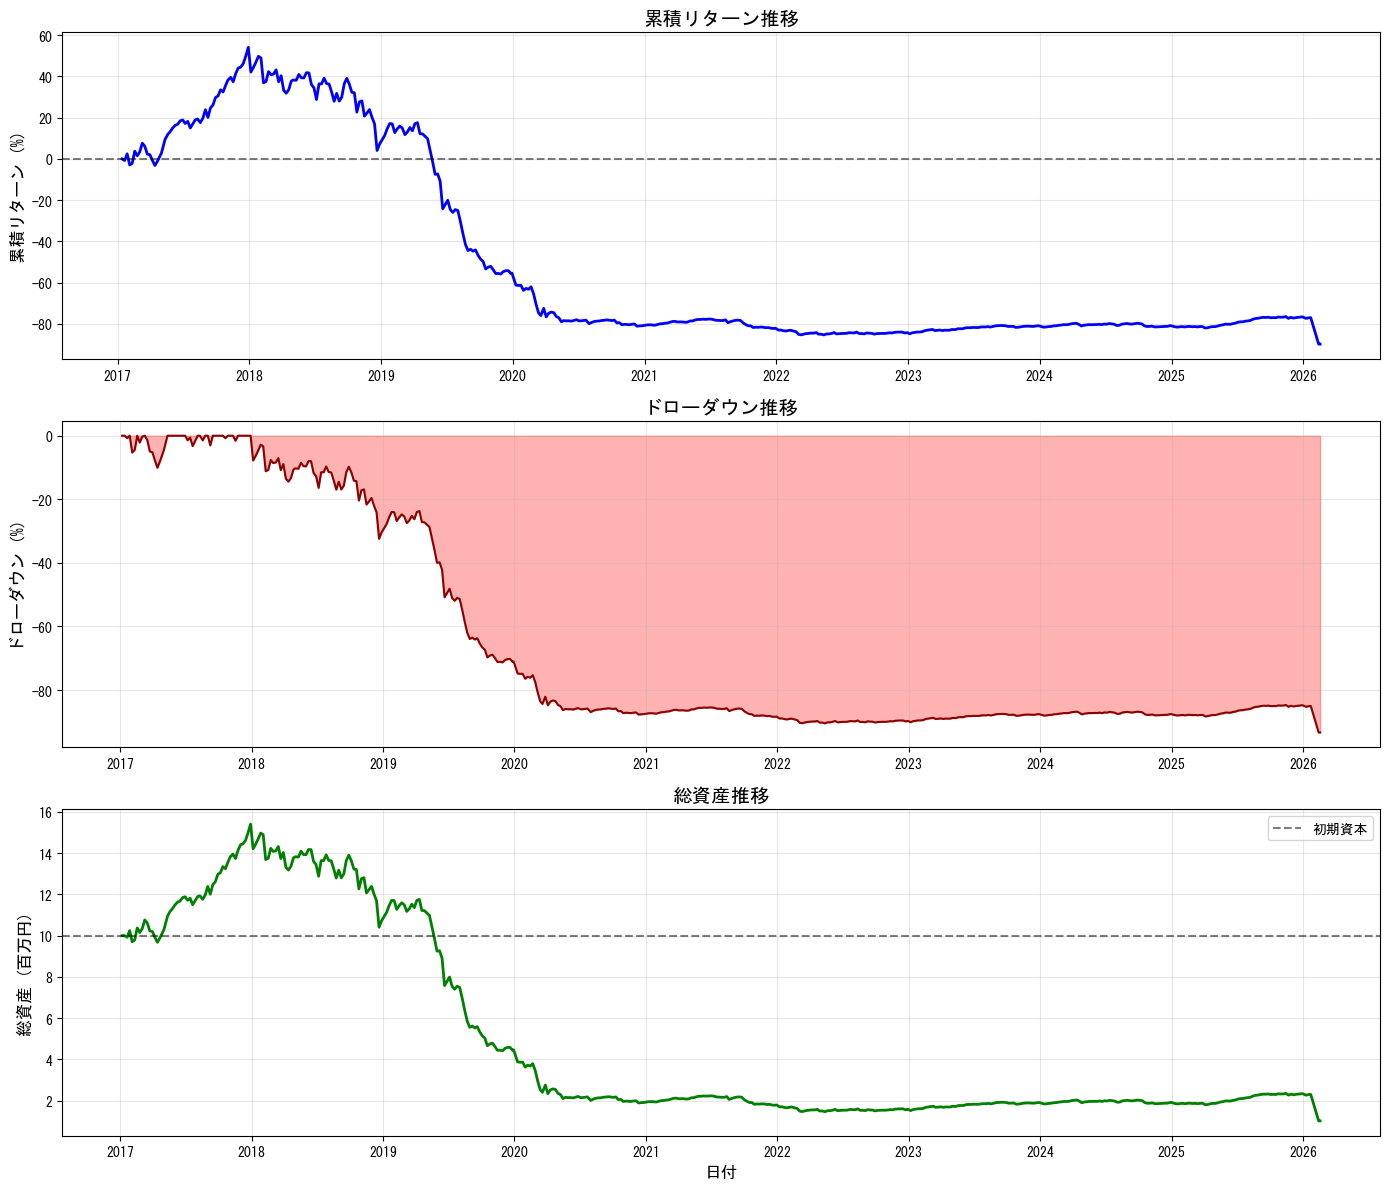

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 累積リターン
axes[0].plot(df_results['date'], df_results['cumulative_return'] * 100, linewidth=2, color='blue')
axes[0].set_title('累積リターン推移', fontsize=14, fontweight='bold')
axes[0].set_ylabel('累積リターン (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# ドローダウン
axes[1].fill_between(df_results['date'], df_results['drawdown'] * 100, 0, alpha=0.3, color='red')
axes[1].plot(df_results['date'], df_results['drawdown'] * 100, color='darkred', linewidth=1.5)
axes[1].set_title('ドローダウン推移', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ドローダウン (%)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# 資産推移
axes[2].plot(df_results['date'], df_results['total_value'] / 1e6, linewidth=2, color='green')
axes[2].axhline(y=INITIAL_CASH/1e6, color='black', linestyle='--', alpha=0.5, label='初期資本')
axes[2].set_title('総資産推移', fontsize=14, fontweight='bold')
axes[2].set_ylabel('総資産 (百万円)', fontsize=12)
axes[2].set_xlabel('日付', fontsize=12)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

## 9. 年次パフォーマンス

In [10]:
df_results['year'] = df_results['date'].dt.year

annual_summary = []
for year in sorted(df_results['year'].unique()):
    year_data = df_results[df_results['year'] == year]
    
    if len(year_data) > 1:
        year_return = (year_data['total_value'].iloc[-1] / year_data['total_value'].iloc[0]) - 1
        year_dd = year_data['drawdown'].min()
        
        annual_summary.append({
            '年': year,
            'リターン(%)': f"{year_return*100:.2f}",
            '最大DD(%)': f"{year_dd*100:.2f}",
            '開始資産(百万円)': f"{year_data['total_value'].iloc[0]/1e6:.2f}",
            '終了資産(百万円)': f"{year_data['total_value'].iloc[-1]/1e6:.2f}",
            'リバランス回数': len(year_data)
        })

df_annual = pd.DataFrame(annual_summary)
print("年次パフォーマンス:")
display(df_annual)

年次パフォーマンス:


,年,リターン(%),最大DD(%),開始資産(百万円),終了資産(百万円),リバランス回数
0,2017,54.08,-10.06,10.00,15.41,52
1,2018,-24.55,-32.45,14.21,10.72,52
2,2019,-59.90,-71.31,11.13,4.46,51
3,2020,-50.39,-87.74,3.88,1.93,52
4,2021,-8.27,-88.45,1.95,1.79,52
5,2022,-7.03,-90.48,1.70,1.58,52
6,2023,25.86,-90.13,1.52,1.91,52
7,2024,3.95,-88.04,1.84,1.92,52
8,2025,25.81,-88.30,1.86,2.34,52
9,2026,-54.93,-93.37,2.27,1.02,5


In [ ]:
# 診断1: 銘柄選定の失敗率
no_stocks = df_results[df_results['n_stocks'] == 0]
print(f"銘柄選定失敗回数: {len(no_stocks)} / {len(df_results)} ({len(no_stocks)/len(df_results)*100:.1f}%)")
print(f"初回失敗: {no_stocks.iloc[0]['date'].date() if len(no_stocks) > 0 else 'なし'}")
print()

# 診断2: 現金比率の推移
df_results['cash_ratio'] = df_results['cash'] / df_results['total_value']
high_cash_periods = df_results[df_results['cash_ratio'] > 0.5]
print(f"現金比率50%超の期間: {len(high_cash_periods)} 回")
print()

# 診断3: 年次損益の詳細
print("年次実現損益（税引前）:")
for year in sorted(df_results['year'].unique()):
    year_data = df_results[df_results['year'] == year]
    if len(year_data) > 1:
        start_pnl = year_data.iloc[0]['annual_pnl']
        end_pnl = year_data.iloc[-1]['annual_pnl']
        print(f"  {year}年: {end_pnl:,.0f}円（開始: {start_pnl:,.0f}円）")
print()

# 診断4: 最悪期間の特定
worst_periods = df_results.nsmallest(10, 'drawdown')[['date', 'total_value', 'drawdown', 'n_stocks', 'cash_ratio']]
print("最悪ドローダウン期間 Top 10:")
display(worst_periods)
print()

# 診断5: ポートフォリオサイズの推移
print("保有銘柄数の統計:")
print(df_results['n_stocks'].describe())
print()

# 診断6: 資産減少が激しい期間
df_results['value_change'] = df_results['total_value'].diff()
worst_drops = df_results.nsmallest(10, 'value_change')[['date', 'total_value', 'value_change', 'n_stocks']]
print("資産減少が最大の週 Top 10:")
display(worst_drops)

## 診断分析: 戦略の問題点を特定

In [ ]:
# 週次 vs 月次 ビジュアル比較
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 累積リターン比較
axes[0].plot(df_results['date'], df_results['cumulative_return'] * 100, 
             linewidth=2, color='blue', label='週次', alpha=0.7)
axes[0].plot(df_results_m['date'], df_results_m['cumulative_return'] * 100, 
             linewidth=2, color='green', label='月次', alpha=0.7)
axes[0].set_title('累積リターン比較: 週次 vs 月次', fontsize=14, fontweight='bold')
axes[0].set_ylabel('累積リターン (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[0].legend(fontsize=12)

# ドローダウン比較
axes[1].fill_between(df_results['date'], df_results['drawdown'] * 100, 0, 
                      alpha=0.3, color='blue', label='週次')
axes[1].plot(df_results['date'], df_results['drawdown'] * 100, 
             color='darkblue', linewidth=1.5, alpha=0.7)
axes[1].fill_between(df_results_m['date'], df_results_m['drawdown'] * 100, 0, 
                      alpha=0.3, color='green', label='月次')
axes[1].plot(df_results_m['date'], df_results_m['drawdown'] * 100, 
             color='darkgreen', linewidth=1.5, alpha=0.7)
axes[1].set_title('ドローダウン比較: 週次 vs 月次', fontsize=14, fontweight='bold')
axes[1].set_ylabel('ドローダウン (%)', fontsize=12)
axes[1].set_xlabel('日付', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# 週次 vs 月次 比較表
comparison = pd.DataFrame({
    '指標': [
        'リバランス回数',
        '最終資産（円）',
        '総リターン（%）',
        '年率リターン（%）',
        '年率ボラティリティ（%）',
        '最大ドローダウン（%）',
        'シャープレシオ',
        'カルマー比'
    ],
    '週次': [
        len(rebalance_dates),
        f"{df_results['total_value'].iloc[-1]:,.0f}",
        f"{df_results['cumulative_return'].iloc[-1]*100:.2f}",
        f"{annual_return*100:.2f}",
        f"{df_results['return'].std() * np.sqrt(52)*100:.2f}",
        f"{mdd*100:.2f}",
        f"{sharpe:.2f}",
        f"{calmar:.2f}"
    ],
    '月次': [
        len(rebalance_dates_monthly),
        f"{df_results_m['total_value'].iloc[-1]:,.0f}",
        f"{df_results_m['cumulative_return'].iloc[-1]*100:.2f}",
        f"{annual_return_m*100:.2f}",
        f"{df_results_m['return'].std() * np.sqrt(12)*100:.2f}",
        f"{mdd_m*100:.2f}",
        f"{sharpe_m:.2f}",
        f"{calmar_m:.2f}"
    ]
})

print("\n週次 vs 月次 リバランス比較")
print("=" * 80)
display(comparison)
print()

# 勝者判定
if df_results_m['total_value'].iloc[-1] > df_results['total_value'].iloc[-1]:
    improvement = (df_results_m['total_value'].iloc[-1] / df_results['total_value'].iloc[-1] - 1) * 100
    print(f"✓ 月次の方が優れています（資産差: +{improvement:.2f}%）")
else:
    decline = (1 - df_results_m['total_value'].iloc[-1] / df_results['total_value'].iloc[-1]) * 100
    print(f"✗ 週次の方が優れています（資産差: -{decline:.2f}%）")

In [ ]:
# 月次パフォーマンス分析
df_results_m = pd.DataFrame(results_m)
df_results_m['total_value'] = df_results_m['cash'] + df_results_m['invested']
df_results_m['return'] = df_results_m['total_value'].pct_change()
df_results_m['cumulative_return'] = (1 + df_results_m['return']).cumprod() - 1

print("=" * 60)
print("月次リバランス - パフォーマンスサマリ")
print("=" * 60)
print(f"期間: {df_results_m['date'].iloc[0].date()} ~ {df_results_m['date'].iloc[-1].date()}")
print(f"初期資本: {INITIAL_CASH:,}円")
print(f"最終資産: {df_results_m['total_value'].iloc[-1]:,.0f}円")
print(f"総リターン: {df_results_m['cumulative_return'].iloc[-1]*100:.2f}%")
print()

# 年率換算
years_m = (df_results_m['date'].iloc[-1] - df_results_m['date'].iloc[0]).days / 365.25
total_return_m = df_results_m['cumulative_return'].iloc[-1]
annual_return_m = (1 + total_return_m) ** (1 / years_m) - 1

print(f"運用期間: {years_m:.2f}年")
print(f"年率リターン: {annual_return_m*100:.2f}%")
print(f"年率ボラティリティ: {df_results_m['return'].std() * np.sqrt(12)*100:.2f}%")

# MDD
df_results_m['peak'] = df_results_m['total_value'].cummax()
df_results_m['drawdown'] = (df_results_m['total_value'] - df_results_m['peak']) / df_results_m['peak']
mdd_m = df_results_m['drawdown'].min()
mdd_date_m = df_results_m.loc[df_results_m['drawdown'].idxmin(), 'date']

print(f"最大ドローダウン: {mdd_m*100:.2f}%（{mdd_date_m.date()}）")

# Sharpe, Calmar
sharpe_m = df_results_m['return'].mean() / df_results_m['return'].std() * np.sqrt(12)
calmar_m = annual_return_m / abs(mdd_m) if mdd_m != 0 else 0

print(f"シャープレシオ: {sharpe_m:.2f}")
print(f"カルマー比: {calmar_m:.2f}")
print("=" * 60)

In [ ]:
# 月次バックテスト実行
cash_m = INITIAL_CASH
portfolio_m = {}
annual_realized_pnl_m = 0
current_year_m = None
results_m = []

print("月次バックテスト開始...")
print(f"初期資本: {INITIAL_CASH:,}円")
print(f"リバランス回数: {len(rebalance_dates_monthly)}")
print()

for i, rebalance_date in enumerate(rebalance_dates_monthly):
    if i % 12 == 0:
        print(f"進捗: {i}/{len(rebalance_dates_monthly)} - {rebalance_date.date()}")
    
    # 年の切り替わり
    if current_year_m != rebalance_date.year:
        if current_year_m is not None and annual_realized_pnl_m > 0:
            tax = annual_realized_pnl_m * TAX_RATE
            cash_m -= tax
        annual_realized_pnl_m = 0
        current_year_m = rebalance_date.year
    
    # 既存ポートフォリオ売却
    sell_value = 0
    if rebalance_date in df_price_pivot.index:
        for code, position in portfolio_m.items():
            if code in df_price_pivot.columns:
                sell_price = df_price_pivot.loc[rebalance_date, code]
                if pd.notna(sell_price):
                    sell_amount = position['shares'] * sell_price
                    sell_value += sell_amount
                    pnl = (sell_price - position['buy_price']) * position['shares']
                    annual_realized_pnl_m += pnl
    
    cash_m += sell_value
    portfolio_m = {}
    
    # 銘柄選定
    selected = screen_stocks_fast(rebalance_date, df_price_pivot, fin_by_date, N_STOCKS)
    
    if len(selected) == 0:
        results_m.append({
            'date': rebalance_date,
            'cash': cash_m,
            'n_stocks': 0,
            'invested': 0,
            'annual_pnl': annual_realized_pnl_m,
            'portfolio': {}
        })
        continue
    
    # 購入
    target_per_stock = cash_m / len(selected)
    total_invested = 0
    
    for _, row in selected.iterrows():
        code = row['code']
        price = row['close']
        shares = int(target_per_stock / (price * UNIT)) * UNIT
        
        if shares > 0:
            invest_amount = shares * price
            total_invested += invest_amount
            portfolio_m[code] = {'shares': shares, 'buy_price': price}
    
    cash_m -= total_invested
    
    results_m.append({
        'date': rebalance_date,
        'cash': cash_m,
        'n_stocks': len(portfolio_m),
        'invested': total_invested,
        'annual_pnl': annual_realized_pnl_m,
        'portfolio': portfolio_m.copy()
    })

# 最終税金
if annual_realized_pnl_m > 0:
    tax = annual_realized_pnl_m * TAX_RATE
    cash_m -= tax
    results_m[-1]['cash'] = cash_m

# 最終日の時価評価
final_portfolio_value_m = 0
if len(portfolio_m) > 0:
    for code, position in portfolio_m.items():
        if code in df_price_pivot.columns:
            final_price = df_price_pivot.loc[final_date, code]
            if pd.notna(final_price):
                final_portfolio_value_m += position['shares'] * final_price
    results_m[-1]['invested'] = final_portfolio_value_m

print("\n月次バックテスト完了")
print(f"最終現金: {cash_m:,.0f}円")
print(f"最終保有銘柄数: {len(portfolio_m)}")
print(f"最終保有株式時価: {final_portfolio_value_m:,.0f}円")
print(f"最終総資産: {(cash_m + final_portfolio_value_m):,.0f}円")

In [ ]:
# 月次リバランス日生成（月末営業日）
trading_days_monthly = pd.DataFrame({'date': df_price_pivot.index})
trading_days_monthly['year'] = trading_days_monthly['date'].dt.year
trading_days_monthly['month'] = trading_days_monthly['date'].dt.month
rebalance_dates_monthly = trading_days_monthly.groupby(['year', 'month'])['date'].max().values
rebalance_dates_monthly = pd.Series(rebalance_dates_monthly).sort_values().reset_index(drop=True)

print(f"月次リバランス日数: {len(rebalance_dates_monthly)}")
print(f"期間: {rebalance_dates_monthly.iloc[0].date()} ~ {rebalance_dates_monthly.iloc[-1].date()}")
print(f"週次との比較: {len(rebalance_dates)} → {len(rebalance_dates_monthly)} （{len(rebalance_dates_monthly)/len(rebalance_dates)*100:.1f}%）")

## 比較分析: 月次リバランス版

## 10. 結果の保存

In [11]:
# 結果をCSVに保存
output_path = PROJECT_ROOT / 'analyses/20260218_1630_weekly_long_only/backtest_results.csv'
df_results.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"結果を保存: {output_path}")

# サマリをテキストファイルに保存
summary_path = PROJECT_ROOT / 'analyses/20260218_1630_weekly_long_only/performance_summary.txt'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(f"週次ロングオンリー戦略 バックテスト結果\n")
    f.write(f"="*60 + "\n")
    f.write(f"期間: {df_results['date'].iloc[0].date()} ~ {df_results['date'].iloc[-1].date()}\n")
    f.write(f"初期資本: {INITIAL_CASH:,}円\n")
    f.write(f"最終資産: {df_results['total_value'].iloc[-1]:,.0f}円\n")
    f.write(f"総リターン: {df_results['cumulative_return'].iloc[-1]*100:.2f}%\n")
    f.write(f"年率リターン: {annual_return*100:.2f}%\n")
    f.write(f"年率ボラティリティ: {df_results['return'].std() * np.sqrt(52)*100:.2f}%\n")
    f.write(f"最大ドローダウン: {mdd*100:.2f}%\n")
    f.write(f"シャープレシオ: {sharpe:.2f}\n")
    f.write(f"カルマー比: {calmar:.2f}\n")

print(f"サマリを保存: {summary_path}")
print("\n完了！")

結果を保存: C:\Users\yongr\claude project\workspace\analyses\20260218_1630_weekly_long_only\backtest_results.csv
サマリを保存: C:\Users\yongr\claude project\workspace\analyses\20260218_1630_weekly_long_only\performance_summary.txt

完了！
